<a href="https://colab.research.google.com/github/KateT840/Electr-nica/blob/main/Gr%C3%A1ficas_osciloscopio_electr%C3%B3nica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
from google.colab import files

nombre_archivo = files.upload()

Saving Lab osciloscopio.csv to Lab osciloscopio (1).csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

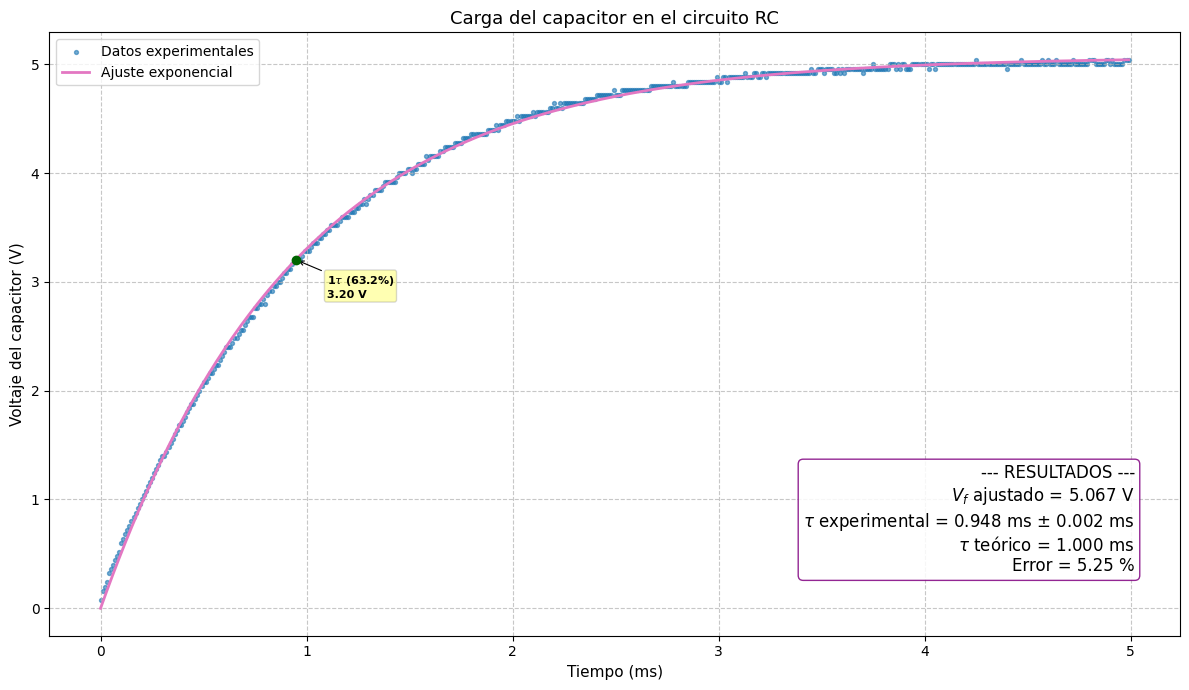

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

nombre_archivo = "Lab osciloscopio.csv"
datos = pd.read_csv(
    nombre_archivo,
    encoding='latin-1',
    header=None,
    usecols=[3, 4, 10],
    names=['Tiempo_s', 'Voltaje_CH1_V', 'Voltaje_CH2_V'])

for col in datos.columns:
    datos[col] = pd.to_numeric(datos[col], errors='coerce')

datos = datos.dropna().reset_index(drop=True)

t = datos['Tiempo_s'].values
V_c = datos['Voltaje_CH2_V'].values

#Región de carga
seleccion = (t >= 0) & (t <= 0.005)

t_carga = t[seleccion] - t[seleccion][0]
V_carga = V_c[seleccion]

# Ajuste
def carga_RC(t, Vf, tau):
    return Vf * (1 - np.exp(-t / tau))

parametros, covarianza = curve_fit(carga_RC, t_carga, V_carga, p0=[5.0, 1e-3])

Vf, tau = parametros
error_tau = np.sqrt(np.diag(covarianza))[1]

# Valores teóricos
R = 10e3
C = 100e-9
tau_teorico = R * C
error_porcentual = abs(tau - tau_teorico) / tau_teorico * 100

#Graficar y cuadro de información
t_ajuste = np.linspace(t_carga.min(), t_carga.max(), 500)
V_ajuste = carga_RC(t_ajuste, Vf, tau)

plt.figure(figsize=(12, 7))

# Datos experimentales y curva ajustada
plt.scatter(t_carga * 1000, V_carga, s=8, color='tab:blue', alpha=0.6, label="Datos experimentales")
plt.plot(t_ajuste * 1000, V_ajuste, color='tab:pink', linewidth=2, label="Ajuste exponencial")

# Puntos clave a destacar (1tau a 5tau)
múltiplos_tau = [1]
porcentajes = [63.2]

for m, pct in zip(múltiplos_tau, porcentajes):
    t_p = m * tau
    V_p = carga_RC(t_p, Vf, tau)

    # Dibujar punto destacado sobre la curva
    plt.plot(t_p * 1000, V_p, 'o', color='darkgreen', markersize=6, zorder=5)

    # Agregar etiqueta explicativa
    plt.annotate(
        f"{m}$\\tau$ ({pct}%)\n{V_p:.2f} V",
        xy=(t_p * 1000, V_p),
        xytext=(t_p * 1000 + 0.15, V_p - 0.35),
        arrowprops=dict(arrowstyle='->', color='black', lw=0.8),
        fontsize=8,
        fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.2", fc="yellow", alpha=0.3, ec="gray"))

# Cuadro de texto con los resultados del experimento
info_texto = (
    f"--- RESULTADOS ---\n"
    f"$V_f$ ajustado = {Vf:.3f} V\n"
    f"$\\tau$ experimental = {tau*1000:.3f} ms $\\pm$ {error_tau*1000:.3f} ms\n"
    f"$\\tau$ teórico = {tau_teorico*1000:.3f} ms\n"
    f"Error = {error_porcentual:.2f} %")

# Colocar el cuadro de texto en la esquina inferior derecha
plt.gca().text(
    0.96, 0.10, info_texto,
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='bottom',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='purple'))

# Configuración final de ejes y cuadrícula
plt.xlabel("Tiempo (ms)", fontsize=11)
plt.ylabel("Voltaje del capacitor (V)", fontsize=11)
plt.title("Carga del capacitor en el circuito RC", fontsize=13)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper left', fontsize=10)

plt.tight_layout()

# -----------------------------------------------------------------------------
# 5. Guardar y descargar la imagen a la computadora automáticamente
# -----------------------------------------------------------------------------
plt.savefig("grafica_carga_RC.png", dpi=300, bbox_inches='tight')
files.download("grafica_carga_RC.png")

plt.show()

In [39]:
nombre_archivo_1 = files.upload()

Saving Lab osciloscopio dos capacitores.csv to Lab osciloscopio dos capacitores.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

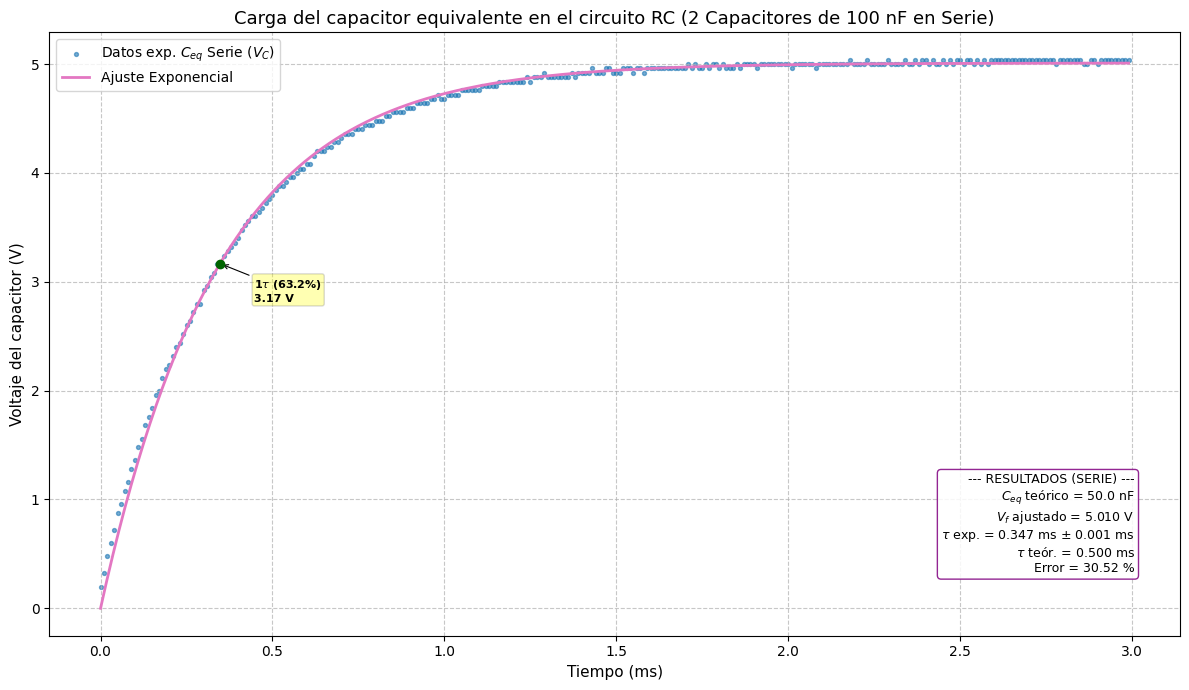

In [46]:
nombre_archivo_1 = "Lab osciloscopio dos capacitores.csv"

datos = pd.read_csv(
    nombre_archivo_1,
    encoding='latin-1',
    header=None,
    usecols=[3, 4, 10],
    names=['Tiempo_s', 'Voltaje_CH1_V', 'Voltaje_CH2_V']
)

for col in datos.columns:
    datos[col] = pd.to_numeric(datos[col], errors='coerce')

datos = datos.dropna().reset_index(drop=True)

t = datos['Tiempo_s'].values
V_c = datos['Voltaje_CH2_V'].values    # CH2: Respuesta del capacitor en serie


# Región de carga
# Al estar en serie (tau ~ 0.5 ms), recortamos de 0 a 3 ms
seleccion = (t >= 0) & (t <= 0.003)

t_carga = t[seleccion] - t[seleccion][0]
V_carga = V_c[seleccion]

# Ajuste no lineal
def carga_RC(t, Vf, tau):
    return Vf * (1 - np.exp(-t / tau))

# Estimación inicial: Vf ~ 5V, tau ~ 0.5ms (5e-4 s)
parametros, covarianza = curve_fit(
    carga_RC,
    t_carga,
    V_carga,
    p0=[5.0, 5e-4]
)

Vf, tau = parametros
error_tau = np.sqrt(np.diag(covarianza))[1]

# Cálculo teórico para capacitores en SERIE: C_eq = C1/2 = 50 nF
R = 10e3
C1 = 100e-9
C2 = 100e-9
C_eq = (C1 * C2) / (C1 + C2)  # 50 nF
tau_teorico = R * C_eq         # 0.5 ms
error_porcentual = abs(tau - tau_teorico) / tau_teorico * 100

#Graficar (Solo Capacitor + Ajuste Exponencial + Puntos Clave)
t_ajuste = np.linspace(t_carga.min(), t_carga.max(), 500)
V_ajuste = carga_RC(t_ajuste, Vf, tau)

plt.figure(figsize=(12, 7))

#Datos experimentales del capacitor equivalente en serie
plt.scatter(
    t_carga * 1000,
    V_carga,
    s=8,
    color='tab:blue',
    alpha=0.6,
    label="Datos exp. $C_{eq}$ Serie ($V_C$)"
)

#Ajuste exponencial
plt.plot(
    t_ajuste * 1000,
    V_ajuste,
    color='tab:pink',
    linewidth=2,
    label="Ajuste Exponencial"
)

# Puntos clave
múltiplos_tau = [1]
porcentajes = [63.2]

for m, pct in zip(múltiplos_tau, porcentajes):
    t_p = m * tau
    V_p = carga_RC(t_p, Vf, tau)

    plt.plot(t_p * 1000, V_p, 'o', color='darkgreen', markersize=6, zorder=5)

    plt.annotate(
        f"{m}$\\tau$ ({pct}%)\n{V_p:.2f} V",
        xy=(t_p * 1000, V_p),
        xytext=(t_p * 1000 + 0.1, V_p - 0.35),
        arrowprops=dict(arrowstyle='->', color='black', lw=0.8),
        fontsize=8,
        fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.2", fc="yellow", alpha=0.3, ec="gray")
    )

# Cuadro de resultados con borde violeta (purple)
info_texto = (
    f"--- RESULTADOS (SERIE) ---\n"
    f"$C_{{eq}}$ teórico = {C_eq*1e9:.1f} nF\n"
    f"$V_f$ ajustado = {Vf:.3f} V\n"
    f"$\\tau$ exp. = {tau*1000:.3f} ms $\\pm$ {error_tau*1000:.3f} ms\n"
    f"$\\tau$ teór. = {tau_teorico*1000:.3f} ms\n"
    f"Error = {error_porcentual:.2f} %"
)

plt.gca().text(
    0.96, 0.10, info_texto,
    transform=plt.gca().transAxes,
    fontsize=9,
    verticalalignment='bottom',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='purple')
)

plt.xlabel("Tiempo (ms)", fontsize=11)
plt.ylabel("Voltaje del capacitor (V)", fontsize=11)
plt.title("Carga del capacitor equivalente en el circuito RC (2 Capacitores de 100 nF en Serie)", fontsize=13)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper left', fontsize=10)

plt.tight_layout()

# -----------------------------------------------------------------------------
# 5. Guardar y descargar
# -----------------------------------------------------------------------------
plt.savefig("grafica_RC_serie_sin_entrada.png", dpi=300, bbox_inches='tight')
files.download("grafica_RC_serie_sin_entrada.png")

plt.show()